# <u>Linear Regression</u>

# 1. Correlation vs Linear Regression

Correlation analysis concerns the <u>degree of a relationship between two variables</u> (when one variable changes, the other also changes). The result is a value between -1.0 and 1.0, where 1.0 denotes the highest positive correlation, -1.0 stands for the highest negative correlation, and 0 means no correlation.

Example: Is there any relationship between purchasing outdoor concert tickets for the next week-end and weather predictions?

<img src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F2c4dd36d-ef1e-45af-8499-b94875043d75_1600x431.png" width="900" height="900"> [Berezovsky, 2023]

Correlation analysis is related to the relationship and connection between two variables.

<u>Linear regression is a function</u>. It's analysis shows how much one variable affects another and how to predict, estimate, or explain its behavior.

If your analysis aims to answer if there is a relationship between X and Y, use correlation. If you aim to answer how X affects Y or have X predict Y, use regression.

<img src="https://substackcdn.com/image/fetch/w_1456,c_limit,f_webp,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F62413fa0-3d80-411c-af93-ebd0f096a26a_1042x644.png" width="500" height="500"> [Berezovsky, 2023]



# 2. Linear Regression

Linear regression analysis is used to predict the value of a variable based on the value of another variable (simple linear regression) or variables (multiple linear regression). 

The variable you want to predict is called the dependent variable. The variable you are using to predict the other variable's value is called the independent variable.

<img src="https://miro.medium.com/v2/resize:fit:2000/format:webp/1*N1-K-A43_98pYZ27fnupDA.jpeg" width="700" height="700"> [Wong, 2020]


### Linear Regression in Machine Learning

<img src="https://www.researchgate.net/profile/Baptiste-Caramiaux/publication/270818818/figure/fig1/AS:392191798202396@1470517219585/Regression-example-of-a-simple-linear-regression-Input-Output-relationship-is-modeled.png" width="500" height="500"> [Caramiaux & Tanaka, 2013]


## Example: Advertising Data

Let's take a look at some data, ask some questions about that data, and then use linear regression to answer those questions.

[James et al., 2021]

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
# Scikit-learn: a software machine learning library used for Linear Regression analysis
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.model_selection import train_test_split
import numpy as np
# this allows plots to appear directly in the notebook
%matplotlib inline

In [2]:
# read data into a DataFrame
data = pd.read_csv('Advertising.csv', index_col=0)

data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


What are the <span style="color:red">**features**</span>?
- TV: advertising dollars spent on TV for a single product in a given market (in thousands of dollars)
- Radio: advertising dollars spent on Radio
- Newspaper: advertising dollars spent on Newspaper

What is the <span style="color:red">**response**</span>?
- Sales: sales of a single product in a given market (in thousands of widgets)

In [3]:
# print the shape of the DataFrame
data.shape

(200, 4)

There are 200 **observations**, and thus 200 markets in the dataset.

<AxesSubplot:xlabel='Newspaper', ylabel='Sales'>

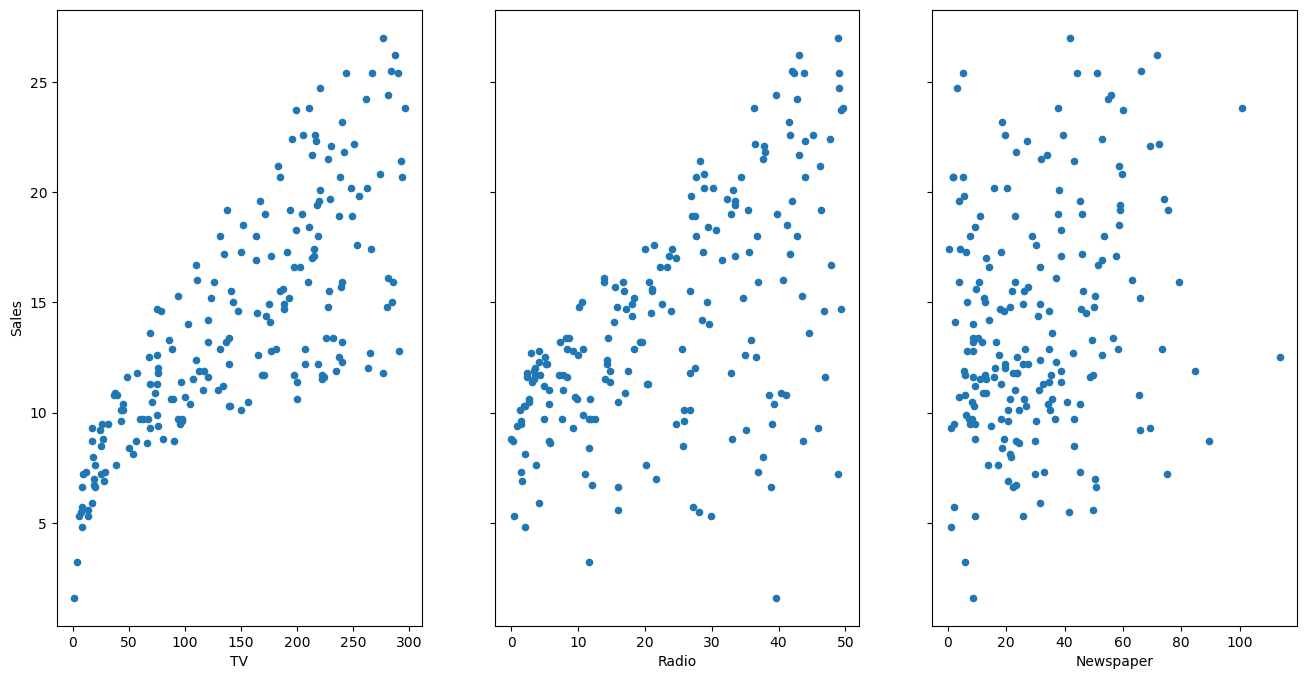

In [5]:
# visualize the relationship between the features and the response using scatterplots
fig, axs = plt.subplots(1, 3, sharey=True, figsize=(16, 8))
data.plot(kind='scatter', x='TV', y='Sales', ax=axs[0])
data.plot(kind='scatter', x='Radio', y='Sales', ax=axs[1])
data.plot(kind='scatter', x='Newspaper', y='Sales', ax=axs[2])

### Questions About the Advertising Data

Let's pretend you work for the company that manufactures and markets this widget. The company might ask you the following: On the basis of this data, <u>how should we spend our advertising money in the future</u>?

This general question might lead you to more specific questions:
1. Is there a <u>relationship</u> between ads and sales?
2. How strong is that relationship?
3. Which ad types contribute to sales?
4. What is the effect of each ad type of sales?
5. Given ad spending, can sales be <u>predicted</u>?

We will explore these questions below.

# 3. Simple Linear Regression

<b>Simple linear regression</b> is an approach for predicting a **quantitative response** using a **single feature** (or "predictor" or "input variable"). It takes the following formula:

$y = \beta_0 + \beta_1x$    

What does each term represent?
- $y$ is the response
- $x$ is the feature
- $\beta_0$ is the intercept
- $\beta_1$ is the coefficient for x

Together, $\beta_0$ and $\beta_1$ are called the **model coefficients**. To create your model, you must "<b>learn</b>" the values of these coefficients. Once we've learned these coefficients, we can use the model to predict Sales.

### Estimating ("Learning") Model Coefficients

Generally speaking, coefficients are estimated using the **least squares criterion**, which means we find the line which minimizes the **sum of squared residuals** (or "sum of squared errors"):

<img src="https://raw.githubusercontent.com/ab2757/Financial_Analytics/master/LinearRegression/Images/08_estimating_coefficients.png">

What elements are present in the diagram?
- The black dots are the **observed values** of x and y.
- The blue line is our **least squares line**.
- The red lines are the **residuals**, which are the distances between the observed values and the least squares line.

How do the model coefficients relate to the least squares line?
- $\beta_0$ is the **intercept** (the value of $y$ when $x$=0)
- $\beta_1$ is the **slope** (the change in $y$ divided by change in $x$)

Here is a graphical depiction of those calculations:

<img src="https://raw.githubusercontent.com/ab2757/Financial_Analytics/master/LinearRegression/Images/08_slope_intercept.png">

Let's use **Scikit-learn** to estimate the model coefficients for the advertising data:

In [6]:
# create X and y
#feature_cols = ['TV']
X = data[['TV']].values
y = data.Sales

# instantiate and fit
linreg = LinearRegression()
model = linreg.fit(X, y)

# print the coefficients
# Beta0
print(linreg.intercept_)

# Beta1
print(linreg.coef_[0])

7.032593549127687
0.047536640433019806


### Interpreting Model Coefficients

How do we interpret the TV coefficient ($\beta_1$)?
- <span style="color:red">A "unit" increase in TV ad spending is **associated with** a 0.047537 "unit" increase in Sales</span>.
- Or more clearly: <span style="color:red">An additional $1,000 spent on TV ads is **associated with** an increase in sales of 47.537 widgets</span>.

Note that if an increase in TV ad spending was associated with a **decrease** in sales, $\beta_1$ would be **negative**.

### Using the Model for Prediction

Let's say that there was a new market where the TV advertising spend was **$50,000**. What would we predict for the Sales in that market? Let's apply the simple linear regression formula.

$$y = \beta_0 + \beta_1x$$
$$y = 7.032594 + 0.047537 \times 50$$
$$y=7.032593549127693 + 0.047536640433019764*50$$
$$y=9,409425571$$

We can also use Scikit-learn to make the prediction:

In [14]:
model.predict([[50], [200]])

array([ 9.40942557, 16.53992164])

(to help interpreting the result, check the Scikit-learn reference for the LinearRegression predict function:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict )

If there was a new market where the TV advertising spend was **$50,000**, we predict Sales of **9,409 widgets** in that market.

### Plotting the Least Squares Line

Let's make predictions for the **smallest and largest observed values of x**, and then use the predicted values to plot the least squares line:

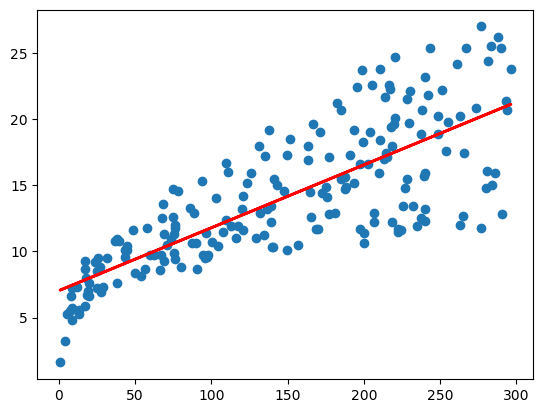

In [16]:
# make predictions
preds = model.predict(X)

# first, plot the observed data
#data.plot(kind='scatter', x='TV', y='Sales')
plt.scatter(data['TV'], data['Sales'])


# then, plot the least squares line between TV and the prediction of Sales
#plt.plot(X, preds, c='red', linewidth=2)
plt.plot(data['TV'], preds, c='red', linewidth=2)

### How Well Does the Model Fit the data?

The most common way to <u>evaluate the overall fit</u> of a linear model is by the **R-squared** value. <span style="color:red">R-squared is the **proportion of variance explained**, meaning the proportion of variance in the observed data that is explained by the model</span>, or the reduction in error over the **null model**. (The null model just predicts the mean of the observed response, and thus it has an intercept and no slope.)

R-squared is between 0 and 1, and <u>higher is better because it means that more variance is explained by the model</u>. Here's an example of what R-squared "looks like":

<img src="https://raw.githubusercontent.com/ab2757/Financial_Analytics/master/LinearRegression/Images/08_r_squared.png">

You can see that the **blue line** explains some of the variance in the data (R-squared=0.54), the **green line** explains more of the variance (R-squared=0.64), and the **red line** fits the training data even further (R-squared=0.66). 

Let's calculate the R-squared value for our simple linear model:

In [27]:
# calculate the R-squared value for the model (by default it uses the R-squared score)
model.score(X, y)

0.611875050850071

**Is that a "good" R-squared value?**

- It's hard to say
- The threshold for a good R-squared value depends widely on the domain
- Therefore, it's most useful as a tool for **comparing different models**

# 4. Multiple Linear Regression

Simple linear regression can easily be extended to include multiple features, which is called <span style="color:red">**multiple linear regression**</span>:

$y = \beta_0 + \beta_1x_1 + ... + \beta_nx_n$

Each $x$ represents a different feature, and each feature has its own coefficient:

$y = \beta_0 + \beta_1 \times TV + \beta_2 \times Radio + \beta_3 \times Newspaper$

Let's estimate these coefficients:

In [12]:
# create X and y
feature_cols = ['TV', 'Radio', 'Newspaper']
X = data[feature_cols].values
y = data.Sales

# instantiate and fit
linreg2 = LinearRegression()
linreg2.fit(X, y)

# print the coefficients
print(linreg2.intercept_)
print(linreg2.coef_)

2.9388893694594014
[ 0.04576465  0.18853002 -0.00103749]


In [13]:
# pair the feature names with the coefficients
list(zip(feature_cols, linreg2.coef_))

[('TV', 0.04576464545539766),
 ('Radio', 0.18853001691820448),
 ('Newspaper', -0.0010374930424762174)]

- For a given amount of Radio and Newspaper spending, an increase of \$1000 in **TV** spending is associated with an **increase in Sales of 45.8 widgets**
- For a given amount of TV and Newspaper spending, an increase of \$1000 in **Radio** spending is associated with an **increase in Sales of 188.5 widgets**.
- For a given amount of TV and Radio spending, an increase of \$1000 in **Newspaper** spending is associated with an **decrease in Sales of 1.0 widgets**. How could that be?

In [14]:
# predict for a new observation
linreg2.predict([[100, 25, 25]])

array([12.20266701])

In [15]:
# calculate the R-squared
linreg2.score(X, y)

0.8972106381789522

**Issure with R-squared**

- **R-squared will always increase as you add more features to the model**, even if they are unrelated to the response
    - Selecting the model with the highest R-squared is not a reliable approach for choosing the best linear model.

**Solution**

- **Train/test split or cross-validation**
    - More reliable estimate of out-of-sample error
    - Better for choosing which of your models will best generalize to out-of-sample data
    - There is extensive functionality for cross-validation in scikit-learn, including automated methods for searching different sets of parameters and different models
    - Importantly, cross-validation can be applied to any model, whereas the methods described above only apply to linear models

# 5. Evaluation metrics for regression problems

Evaluation metrics for classification problems, such as **accuracy**, are not useful for regression problems. We need evaluation metrics designed for comparing **continuous values**.

Let's create some example numeric predictions, and calculate <u>three common evaluation metrics for regression problems</u>:
#### Define true and predicted response values

In [26]:
y_true = y
y_pred = linreg2.predict(X)

**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:
$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$
**Mean Squared Error** (MSE) is the mean of the squared errors:
$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$
 **Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:
$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

In [27]:
# calculate MAE, MSE, RMSE
print('Mean Absolute Error: ', metrics.mean_absolute_error(y_true, y_pred))
print('Mean Squared Error: ', metrics.mean_squared_error(y_true, y_pred))
print('Root Mean Squared Error: ', np.sqrt(metrics.mean_squared_error(y_true, y_pred)))

Mean Absolute Error:  1.2520112296870682
Mean Squared Error:  2.784126314510936
Root Mean Squared Error:  1.6685701407225697


### Comparing these metrics:
- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

#### <span style='color:red'> All of these are **loss functions** - we want to minimize them</span>.


## Using train/test split (or cross-validation)

### A better approach to feature selection!
- It attempts to directly estimate how well your model will **generalize** to out-of-sample data.
- It relys on **fewer assumptions** that linear regression.
- It can easily be applied to **any model**, not just linear models.

### Let's define functions accepting X and y and computing RMSE and MAE

In [2]:
def train_test_rmse(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
    linreg = LinearRegression()
    model = linreg.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return np.sqrt(metrics.mean_squared_error(y_test, y_pred))

def train_test_mae(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
    linreg = LinearRegression()
    model = linreg.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return metrics.mean_absolute_error(y_test, y_pred)

### Now, let's try RMSE with the features 'TV', 'Radio', and 'Newspaper'

In [13]:
feature_cols = ['TV', 'Radio', 'Newspaper']
X = data[feature_cols]
train_test_rmse(X, y)

1.4113417558581565

Hmm, is there any chance that we can lower the RMSE value? We can try <u>exclude the least correlated features</u>. Let's try to see which ones are correlated the least:

In [29]:
# import Seaborn visualization library
%pip install seaborn
import seaborn as sns

# plot the heatmap
sns.heatmap(data.corr(), annot=True)


<AxesSubplot:>

<span style='color:red'>The least correlated feature with Sales is Newspaper, so let's exclude Newspaper !</span>

1.3982924890777726

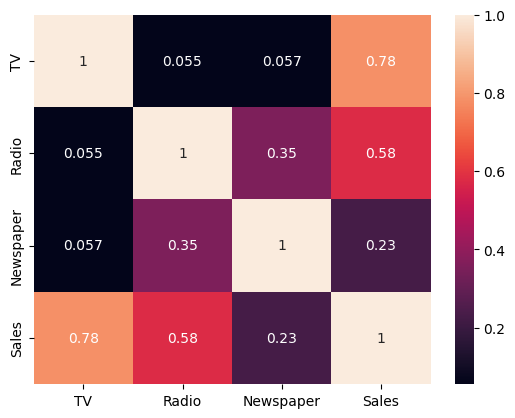

In [17]:
feature_cols = ['TV', 'Radio']
X = data[feature_cols]
train_test_rmse(X, y)

**Voilá! A lower RMSE as expected!**

# 6. Comparing linear regression with other models

## Advantages of linear regression:
- Simple to explain
- Highly interpretable
- Model training and prediction are fast
- No tuning is required (excluding regularization)
- Features don't need scaling
- Can perform well with a small number of observations

## Disadvantages of linear regression:
- Presumes a linear relationship between the features and the response
- Performance is (generally) not competitive with the best supervised learning methods due to high bias
- Sensitive to irrelevant features
- Can't automatically learn feature interactions

# 7. Bibliography


[Berezovsky, 2023] Olga Berezovsky, "How to do linear regression and correlation analysis", Lenny's Newsletter, available at https://www.lennysnewsletter.com/p/linear-regression-and-correlation-analysis

[Caramiaux & Tanaka, 2013] Baptiste Caramiaux, Atau Tanaka, "Machine Learning of Musical Gestures", Proceedings of the International Conference on New Interfaces For Musical Expression (NIME), available at https://www.researchgate.net/publication/270818818_Machine_Learning_of_Musical_Gestures

[James et al., 2021], Gareth James, Daniela Witten, Trevor Hastie, Robert Tibshirani, "An Introduction to Statistical Learning: with Applications in R, 2021 Edition", Ed.Springer, available at https://static1.squarespace.com/static/5ff2adbe3fe4fe33db902812/t/6009dd9fa7bc363aa822d2c7/1611259312432/ISLR+Seventh+Printing.pdf

[Wong, 2020] Jason Wong, "Linear Regression Explained", Medium, available at https://towardsdatascience.com/linear-regression-explained-1b36f97b7572 

